In [62]:
import numpy as np
import numpy.linalg as LA
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from matplotlib import colors
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import neighbors
from matplotlib.colors import ListedColormap
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split

LDA/QDA for la_1.txt

LDA training Error:0.0600
QDA training Error:0.0650


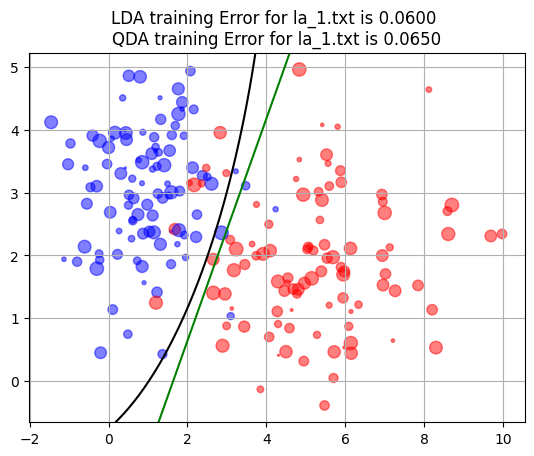

In [63]:
#匯入資料
data_dir = 'Data/'
D = np.loadtxt(data_dir + 'la_1.txt', comments='%')
# -----------------------------------------------------------------
#畫圖
# area=50+D[:,2]
area=2*np.random.randint(50,size=D[:,0].size)
color=['red' if i == 0 else 'blue' for i in D[:,2]]
plt.scatter(D[:,0], D[:,1], c=color,s=area,alpha=0.5,marker='o')
plt.grid(True)
# -----------------------------------------------------------------
#定義顏色
cdit = {'red': [(0, 1, 1), (1, 0.7, 0.7)],
'green': [(0, 0.7, 0.7), (1, 0.7, 0.7)],
'blue': [(0, 0.7, 0.7), (1, 1, 1)]}
cmap = colors.LinearSegmentedColormap(
'red_blue_classes', cdit)
# -----------------------------------------------------------------

X = D[:, 0:2]
y = D[:,2]
#LDA學習器(線)
Lda = LinearDiscriminantAnalysis()
Lda.fit(X, y)
K = Lda.intercept_
L = Lda.coef_
MissClassRateLDA = 1 - Lda.score(X, y)
print('LDA training Error:{:.4f}'.format(MissClassRateLDA))
nx,ny=100,100
x_min,x_max=plt.xlim()
y_min,y_max=plt.ylim()
x_=np.linspace(x_min,x_max,nx)
y_=np.linspace(y_min,y_max,ny)
xx,yy=np.meshgrid(x_,y_)
Z=Lda.predict_proba(np.c_[xx.ravel(),yy.ravel()])
Z=Z[:,1].reshape(xx.shape)#取第一行也可以，因為只有兩組，知道一個便知道另一個
contoursLDA=plt.contour(xx,yy,Z,[0.5],colors='g')
# plt.pcolormesh(xx,yy,Z,cmap='red_blue_classes',\
#   norm=colors.Normalize(0.,1.),\
#    shading='auto',zorder=0 )
# -----------------------------------------------------------------
# QDA學習器
Qda = QuadraticDiscriminantAnalysis(\
tol = 1e-6, store_covariance = True)
Qda.fit(X, y)
trainErrorQDA=1-Qda.score(X,y)
Z = Qda.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z[:, 1].reshape(xx.shape)
# plt.pcolormesh(xx,yy,Z,cmap='red_blue_classes',\
#   norm=colors.Normalize(0.,1.),\
#        shading='auto',zorder=0)
contoursQDA=plt.contour(xx,yy,Z,[0.5],colors='k')
print('QDA training Error:{:.4f}'.format(trainErrorQDA))
# -----------------------------------------------------------------
plt.title('LDA training Error for la_1.txt is 0.0600 \nQDA training Error for la_1.txt is 0.0650')
plt.show()

KNN for la_1.txt

Text(0.5, 1.0, 'Training error = 0.0600 for K = 25')

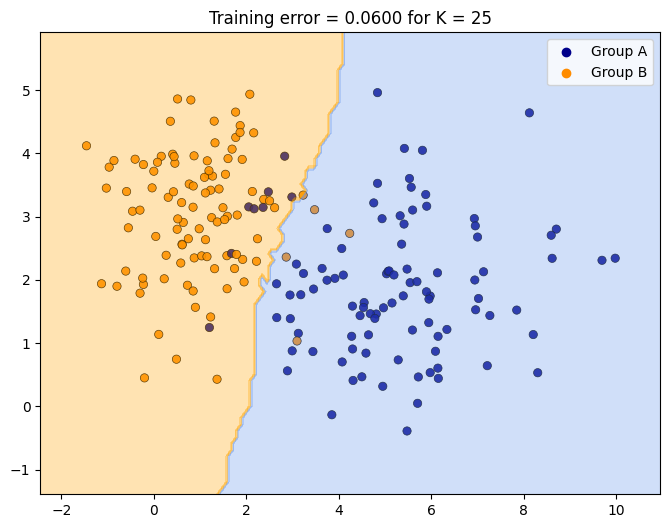

In [53]:
#匯入資料
data_dir = 'Data/'
D = np.loadtxt(data_dir + 'la_1.txt', comments='%')
# -----------------------------------------------------------------
#取資料範圍
X = D[:, 0:2]
y = D[:,2].astype('int') # convert to integers
n = len(y)
# -----------------------------------------------------------------
#定義圖片格式
cmap_bold = ['darkblue', 'darkorange']
Group_name = np.array(['Group A', 'Group B'])
plt.figure(figsize=(8, 6))
sns.scatterplot(x = X[:, 0], y = X[:, 1], \
    hue = Group_name[y], palette = cmap_bold, \
    alpha = 0.9, edgecolor = 'black')
# -----------------------------------------------------------------  
# KNN learning
K = 25
weights = 'uniform'
Knn = neighbors.KNeighborsClassifier(K, weights = weights)
Knn.fit(X, y)
trainingErr = 1 - Knn.score(X, y)
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),\
    np.arange(y_min, y_max, 0.1))
z = Knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = z.reshape(xx.shape)
cmap_light = ListedColormap(['cornflowerblue', 'orange'])
plt.contourf(xx, yy, Z, cmap = cmap_light, alpha = 0.3)
plt.title('Training error = %.4f for K = %i' % (trainingErr,K))

資料生成

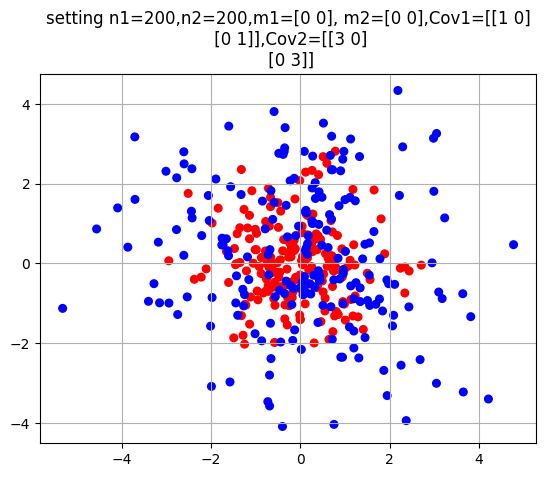

In [65]:
n1, n2 = 200, 200
m1, m2 = np.array([0, 0]), np.array([0, 0])
Cov1 = np.array([[1, 0], [0, 1]])
Cov2 = np.array([[3, 0], [0,3]])

mvn1 = multivariate_normal(mean = m1, cov = Cov1)
mvn2 = multivariate_normal(mean = m2, cov = Cov2)

A, B = mvn1.rvs(n1), mvn2.rvs(n2)
X = np.vstack((A, B))
y = np.hstack((np.zeros(n1), np.ones(n2)))

np.savetxt('demo_data.txt', np.c_[X, y],\
fmt = '%.4f %.4f %d', header = 'X1 X2 y')

colors = ['red' if i == 0 else 'blue' for i in y]

plt.scatter(X[:, 0], X[:, 1], \
c=colors, s=30, marker='o')
plt.title('setting n1={},n2={},m1={}, m2={},Cov1={},Cov2={}'.format(n1,n2,m1,m2,Cov1,Cov2))
plt.grid(True)
plt.show()
# -----------------------------------------------------------------


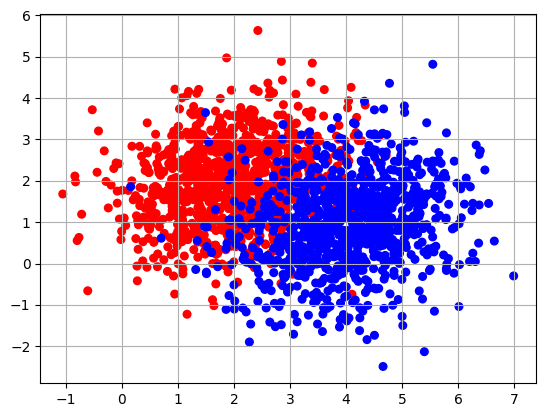

LDA training Error:0.1148
LDA testing Error:0.1162
QDA training Error:0.1150
QDA testing Error:0.1160
KNN5 training Error:0.0974
KNN5 testing Error:0.0980
KNN10 training Error:0.1117
KNN10 testing Error:0.1131


In [13]:
import numpy as np
import numpy.linalg as LA
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from matplotlib import colors
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import neighbors
from matplotlib.colors import ListedColormap
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split
# -----------------------------------------------------------------  
n1, n2 = 1000, 1000
m1, m2 = np.array([2, 2]), np.array([4, 1])
Cov1 = np.array([[1, 0.2], [0.2, 1]])
Cov2 = np.array([[1, 0.2], [0.2,1]])

mvn1 = multivariate_normal(mean = m1, cov = Cov1)
mvn2 = multivariate_normal(mean = m2, cov = Cov2)

A, B = mvn1.rvs(n1), mvn2.rvs(n2)
X = np.vstack((A, B))
y = np.hstack((np.zeros(n1), np.ones(n2)))
np.savetxt('demo_data.txt', np.c_[X, y],\
fmt = '%.4f %.4f %d', header = 'X1 X2 y')

colors = ['red' if i == 0 else 'blue' for i in y]

plt.scatter(X[:, 0], X[:, 1], \
c=colors, s=30, marker='o')
# plt.title('setting n1={},n2={},m1={}, m2={},Cov1={},Cov2={}'.format(n1,n2,m1,m2,Cov1,Cov2))
plt.grid(True)
plt.show()
# -----------------------------------------------------------------  
weights = 'uniform'
K =100
LDA_trainingError,LDA_testingError = np.zeros(K),np.zeros(K)
QDA_trainingError,QDA_testingError = np.zeros(K),np.zeros(K)
Knn5_trainingError,Knn5_testingError = np.zeros(K),np.zeros(K)
Knn10_trainingError,Knn10_testingError = np.zeros(K),np.zeros(K)
# 學習器設定
Lda = LinearDiscriminantAnalysis(tol = 1e-6)
Qda = QuadraticDiscriminantAnalysis(tol = 1e-6, store_covariance = True)
Knn5 = neighbors.KNeighborsClassifier(5, weights = weights)
Knn10 = neighbors.KNeighborsClassifier(10, weights = weights)
# -----------------------------------------------------------------  
# trainingErr
for i in range(K) :
# split data into TRAINing and TESTing parts
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
    Lda.fit(X_train, y_train)
    LDA_trainingError[i] = 1 - Lda.score(X_train, y_train)
    LDA_testingError[i] = 1 - Lda.score(X_test, y_test)
    Qda.fit(X_train, y_train)
    QDA_trainingError[i] = 1 - Qda.score(X_train, y_train)
    QDA_testingError[i] = 1 - Qda.score(X_test, y_test)
    Knn5.fit(X, y)
    Knn5_trainingError[i] = 1 - Knn5.score(X_train, y_train)
    Knn5_testingError[i] = 1 - Knn5.score(X_test, y_test)
    Knn10.fit(X, y)
    Knn10_trainingError[i] = 1 - Knn10.score(X_train, y_train)
    Knn10_testingError[i] = 1 - Knn10.score(X_test, y_test)
print('LDA training Error:{:.4f}'.format(LDA_trainingError.mean()))
print('LDA testing Error:{:.4f}'.format(LDA_testingError.mean()))
print('QDA training Error:{:.4f}'.format(QDA_trainingError.mean()))
print('QDA testing Error:{:.4f}'.format(QDA_testingError.mean()))
print('KNN5 training Error:{:.4f}'.format(Knn5_trainingError.mean()))
print('KNN5 testing Error:{:.4f}'.format(Knn5_testingError.mean()))
print('KNN10 training Error:{:.4f}'.format(Knn10_trainingError.mean()))
print('KNN10 testing Error:{:.4f}'.format(Knn10_testingError.mean()))

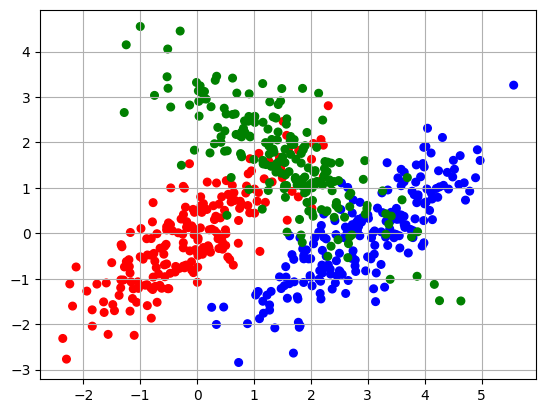

LDA training Error:0.1511
LDA testing Error:0.1488
QDA training Error:0.1012
QDA testing Error:0.1001
KNN5 training Error:0.1057
KNN5 testing Error:0.1021
KNN10 training Error:0.1056
KNN10 testing Error:0.1026


In [1]:
import numpy as np
import numpy.linalg as LA
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from matplotlib import colors
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import neighbors
from matplotlib.colors import ListedColormap
from scipy.stats import multivariate_normal
from sklearn.model_selection import train_test_split
# -----------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

n1, n2, n3 = 200, 200, 200  # 2組資料內的各樣本數
m1, m2, m3 = np.array([0, 0]), np.array([3, 0]), np.array([1.5, 1.7])  # 2維 normal的中心點
Cov1 = np.array([[1, 0.8], [0.8, 1]])
Cov2 = np.array([[1, 0.8], [0.8, 1]])
Cov3 = np.array([[1, -0.8], [-0.8, 1]])

mvn1 = multivariate_normal(mean=m1, cov=Cov1)
mvn2 = multivariate_normal(mean=m2, cov=Cov2)
mvn3 = multivariate_normal(mean=m3, cov=Cov3)
A, B, C = mvn1.rvs(n1), mvn2.rvs(n2), mvn3.rvs(n3)
X = np.vstack((A, B, C))
y = np.hstack((np.zeros(n1), np.ones(n2), 2*np.ones(n3)))

np.savetxt('demo_data.txt', np.c_[X, y],
           fmt='%.4f %.4f %d', header='X1 X2 X3 y')

colors = ['red' if i == 0 else 'blue' if i == 1 else 'green' for i in y]

plt.scatter(X[:, 0], X[:, 1], c=colors, s=30, marker='o')
plt.grid(True)
plt.show()
# -----------------------------------------------------------------
weights = 'uniform'
K = 100
LDA_trainingError, LDA_testingError = np.zeros(K), np.zeros(K)
QDA_trainingError, QDA_testingError = np.zeros(K), np.zeros(K)
Knn5_trainingError, Knn5_testingError = np.zeros(K), np.zeros(K)
Knn10_trainingError, Knn10_testingError = np.zeros(K), np.zeros(K)
# 學習器設定
Lda = LinearDiscriminantAnalysis(tol=1e-6)
Qda = QuadraticDiscriminantAnalysis(tol=1e-6, store_covariance=True)
Knn5 = neighbors.KNeighborsClassifier(5, weights=weights)
Knn10 = neighbors.KNeighborsClassifier(10, weights=weights)
# -----------------------------------------------------------------
# trainingErr
for i in range(K):
    # split data into TRAINing and TESTing parts
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    Lda.fit(X_train, y_train)
    LDA_trainingError[i] = 1 - Lda.score(X_train, y_train)
    LDA_testingError[i] = 1 - Lda.score(X_test, y_test)
    Qda.fit(X_train, y_train)
    QDA_trainingError[i] = 1 - Qda.score(X_train, y_train)
    QDA_testingError[i] = 1 - Qda.score(X_test, y_test)
    Knn5.fit(X, y)
    Knn5_trainingError[i] = 1 - Knn5.score(X_train, y_train)
    Knn5_testingError[i] = 1 - Knn5.score(X_test, y_test)
    Knn10.fit(X, y)
    Knn10_trainingError[i] = 1 - Knn10.score(X_train, y_train)
    Knn10_testingError[i] = 1 - Knn10.score(X_test, y_test)
print('LDA training Error:{:.4f}'.format(LDA_trainingError.mean()))
print('LDA testing Error:{:.4f}'.format(LDA_testingError.mean()))
print('QDA training Error:{:.4f}'.format(QDA_trainingError.mean()))
print('QDA testing Error:{:.4f}'.format(QDA_testingError.mean()))
print('KNN5 training Error:{:.4f}'.format(Knn5_trainingError.mean()))
print('KNN5 testing Error:{:.4f}'.format(Knn5_testingError.mean()))
print('KNN10 training Error:{:.4f}'.format(Knn10_trainingError.mean()))
print('KNN10 testing Error:{:.4f}'.format(Knn10_testingError.mean()))
